In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math

## Zadanie 1

In [4]:
x0 = 1.0
machine_epsilon = np.finfo(float).eps
k = np.arange(17)
h = 10.0**(-k)

In [5]:
f_x0 = np.tan(x0)
exact_derivative = 1.0 + f_x0**2
exact_second_derivative = 2.0 * f_x0 * exact_derivative
exact_third_derivative = 6* f_x0**4 + 8* f_x0**2 + 2

#### Wartość pochodniej w prost

In [6]:
approx_derivative = (np.tan(x0 + h) - f_x0) / h

In [7]:
error_computational = np.abs(approx_derivative - exact_derivative)
error_method = (np.abs(exact_second_derivative) / 2.0) * h
error_numerical = (2.0 * machine_epsilon * np.abs(f_x0)) / h

In [8]:
h_min_empirical = h[np.argmin(error_computational)]
h_min_theoretical = 2.0 * np.sqrt(machine_epsilon / np.abs(exact_second_derivative))

#### Wartość pochodnej ze wzoru roznic centralnych

In [9]:
approx_central_derivative = (np.tan(x0 + h) - np.tan(x0 - h)) / (2.0 * h)

In [10]:
central_error_computational = np.abs(approx_central_derivative - exact_derivative)
central_error_method = (np.abs(exact_third_derivative) / 6.0) * h**2
central_error_numerical = (machine_epsilon * np.abs(f_x0)) / h

In [11]:
central_h_min_empirical = h[np.argmin(central_error_computational)]
central_h_min_theoretical = np.cbrt(3.0 * machine_epsilon / np.abs(exact_third_derivative))

In [ ]:
print(f"Minimalny bład w przód = {np.min(error_computational)}")
print(f"Minimalny bład centralny = {np.min(central_error_computational)}")

minimalny bład w przód = 2.554135347665465e-08
minimalny bład centralny = 6.2239102760486276e-12


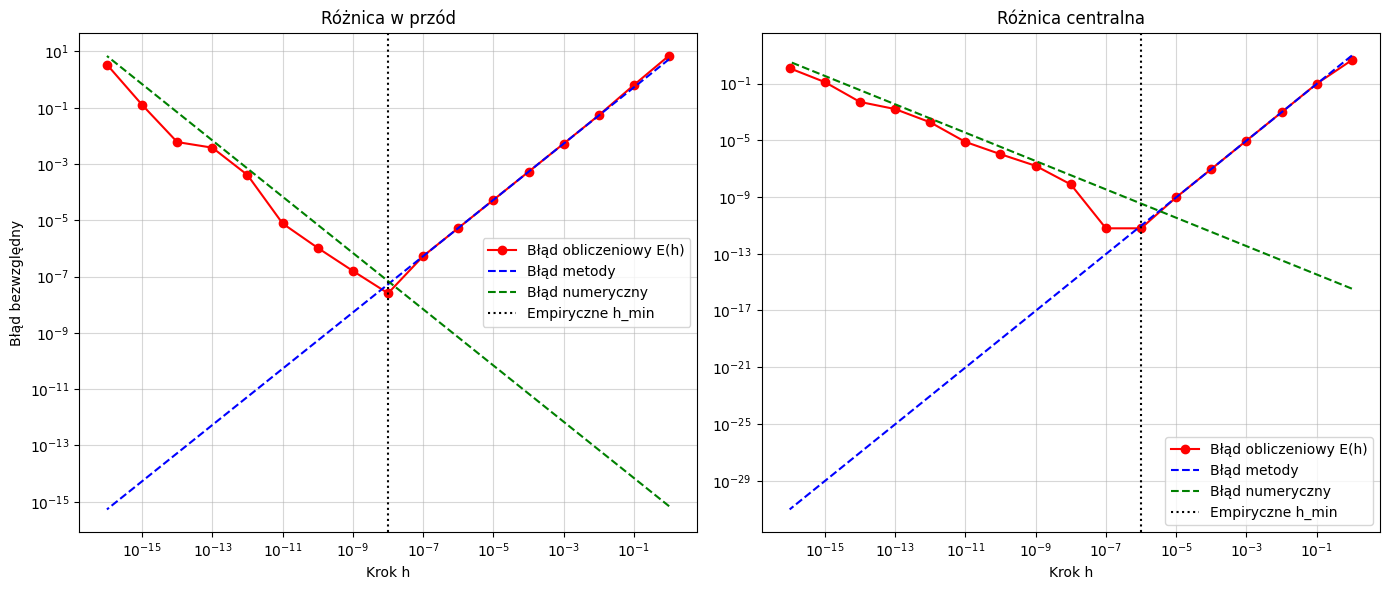

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# --- Wykres 1: Różnica w przód ---
axs[0].loglog(h, error_computational, 'ro-', label='Błąd obliczeniowy E(h)')
axs[0].loglog(h, error_method, 'b--', label='Błąd metody')
axs[0].loglog(h, error_numerical, 'g--', label='Błąd numeryczny')
axs[0].axvline(h_min_empirical, color='k', linestyle=':', label='Empiryczne h_min')

axs[0].set_xlabel('Krok h')
axs[0].set_ylabel('Błąd bezwzględny')
axs[0].set_title('Różnica w przód')
axs[0].grid(True, which="both", ls="-", alpha=0.5)
axs[0].legend()

# --- Wykres 2: Różnica centralna ---
axs[1].loglog(h, central_error_computational, 'ro-', label='Błąd obliczeniowy E(h)')
axs[1].loglog(h, central_error_method, 'b--', label='Błąd metody')
axs[1].loglog(h, central_error_numerical, 'g--', label='Błąd numeryczny')
axs[1].axvline(central_h_min_empirical, color='k', linestyle=':', label='Empiryczne h_min')

axs[1].set_xlabel('Krok h')
axs[1].set_title('Różnica centralna')
axs[1].grid(True, which="both", ls="-", alpha=0.5)
axs[1].legend()

plt.tight_layout()
plt.show()

## Zadanie 2

(a) $f(x) = \sqrt{x + 1} - 1$ dla $x \approx 0$
Wersja stabilna: $\frac{x}{\sqrt{x + 1} + 1}$

(b) $f(x, y) = x^2 - y^2$ dla $x \approx y$
Wersja stabilna: $(x - y)(x + y)$

(c) $f(x) = \frac{1 - \cos x}{\sin x}$ dla $x \approx 0
Wersja stabilna: $\frac{\sin x}{1 + \cos x}$ lub bezpośrednio $\tan(\frac{x}{2})$

(d) $f(x, y) = \sin x - \sin y$ dla $x \approx y$
Wersja stabilna: $2 \sin(\frac{x - y}{2}) \cos(\frac{x + y}{2})$

(e) $f(a, b) = \frac{a + b}{2}$ 
Wersja stabilna: $a + \frac{b - a}{2}$ dla a,b tych samych znaków, $\frac{a + b}{2}$ gdy sa przeciwnych znaków

(f) $\text{softmax}(x)_i = \frac{\exp(x_i)}{\sum_j \exp(x_j)}$
Wersja stabilna: $\frac{\exp(x_i - \max(x))}{\sum_j \exp(x_j - \max(x))}$

In [13]:
import decimal
decimal.getcontext().prec = 5

#### Podpunkt (a)

In [14]:
a = np.int8(126)
b = np.int8(124)

In [15]:
unstable_a = (a+b)/2
stable_a = a + (b-a)/2

/var/folders/lj/kgt2xwx15_gbb8_x3wb7867c0000gn/T/ipykernel_29644/2786448639.py:1: RuntimeWarning: overflow encountered in scalar add
  unstable_a = (a+b)/2


In [17]:
print("--- Podpunkt (e) ---")
print(f"Dane wejściowe: a = {a} , b={b}")
print(f"Wynik niestabilny: {unstable_a}")
print(f"Wynik stabilny:    {stable_a}\n")

--- Podpunkt (e) ---
Dane wejściowe: a = 126 , b=124
Wynik niestabilny: -3.0
Wynik stabilny:    125.0



#### Podpunkt (b)

In [54]:
x_val = decimal.Decimal('100.100')
y_val = decimal.Decimal('100.099')

In [57]:
unstable_b = x_val**2 - y_val**2
stable_b = (x_val - y_val) * (x_val + y_val)

In [58]:
print("--- Podpunkt (b): x^2 - y^2 dla x ~ y ---")
print(f"Dane: x = {x_val}, y = {y_val}")
print(f"Wynik niestabilny: {unstable_b}")
print(f"Wynik stabilny:    {stable_b}\n")

--- Podpunkt (b): x^2 - y^2 dla x ~ y ---
Dane: x = 100.100, y = 100.099
Wynik niestabilny: 0
Wynik stabilny:    0.20020



## Zadanie 3

In [19]:
f_original = (np.exp(h) - 1.0) / h

In [20]:
y_values = np.exp(h)
f_equivalent = np.where(y_values == 1.0, 1.0, (y_values - 1.0) / np.log(y_values))

C:\Users\matis\AppData\Local\Temp\ipykernel_11016\2531226811.py:2: RuntimeWarning: invalid value encountered in divide
  f_equivalent = np.where(y_values == 1.0, 1.0, (y_values - 1.0) / np.log(y_values))


In [21]:
f_taylor = 1.0 + (h / 2.0) + (h**2 / 6.0)

In [22]:
f_expm1 = np.expm1(h) / h

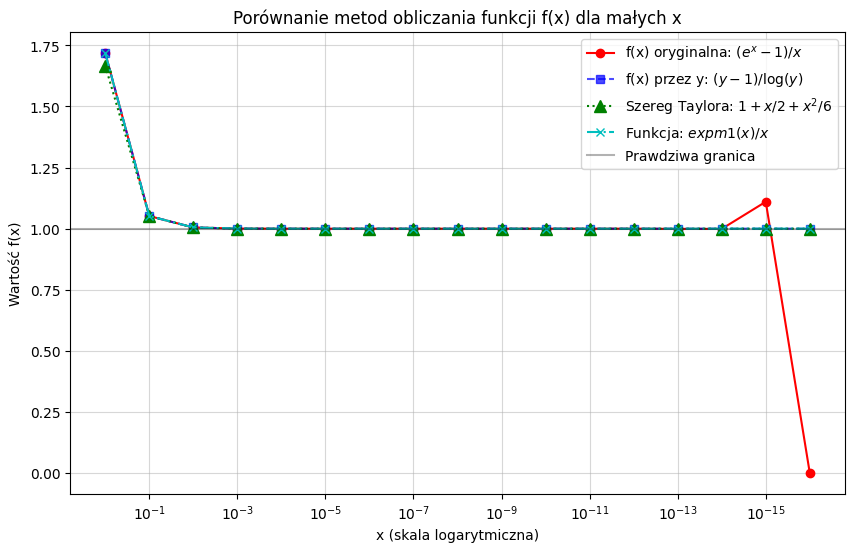

In [23]:
plt.figure(figsize=(10, 6))

plt.semilogx(h, f_original, 'ro-', label='f(x) oryginalna: $(e^x - 1)/x$')
plt.semilogx(h, f_equivalent, 'bs--', label='f(x) przez y: $(y - 1)/\log(y)$', alpha=0.7)
plt.semilogx(h, f_taylor, 'g^:', label='Szereg Taylora: $1 + x/2 + x^2/6$', markersize=8)
plt.semilogx(h, f_expm1, 'cx-.', label='Funkcja: $expm1(x)/x$')

plt.axhline(1.0, color='k', linestyle='-', alpha=0.3, label='Prawdziwa granica')

plt.title('Porównanie metod obliczania funkcji f(x) dla małych x')
plt.xlabel('x (skala logarytmiczna)')
plt.ylabel('Wartość f(x)')
plt.gca().invert_xaxis()
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

## Zadanie 4

#### Podpunkt (a)

In [24]:
def sum_double_precision(data_array):
    suma = np.float64(0.0)
    for xi in data_array:
        suma += np.float64(xi)
    return suma

#### Podpunkt (b)

In [25]:
def sum_single_precision(data_array):
    suma = np.float32(0.0)
    for xi in data_array:
        suma += np.float32(xi)
    return suma

#### Podpunkt (c)

In [26]:
def sum_kahan(data_array):
    kahan_sum = np.float32(0.0)
    compensation = np.float32(0.0)
    for value in data_array:
        corrected_value = value - compensation
        temp_sum = kahan_sum + corrected_value
        compensation = (temp_sum - kahan_sum) - corrected_value
        kahan_sum = temp_sum
    return kahan_sum

#### Podpunkt (d)

In [27]:
def sum_ascending(data_array):
    data_array = np.sort(data_array)
    suma = np.float32(0.0)
    for xi in data_array:
        suma += np.float32(xi)
    return suma

#### Podpunkt (e)

In [28]:
def sum_descending(data_array):
    data_array = np.sort(data_array)[::-1]
    suma = np.float32(0.0)
    for xi in data_array:
        suma += np.float32(xi)
    return suma

#### Rysowanie wykresu

In [29]:
k_powers = np.arange(4, 9)
n_sizes = 10**k_powers
num_tests = len(n_sizes)

In [30]:
err_a = np.zeros(num_tests)
err_b = np.zeros(num_tests)
err_c = np.zeros(num_tests)
err_d = np.zeros(num_tests)
err_e = np.zeros(num_tests)

In [31]:
for idx, n in enumerate(n_sizes):
    random_data = np.random.uniform(0, 1, n).astype(np.float32)
    exact_value = math.fsum(random_data)
    
    err_a[idx] = np.abs(sum_double_precision(random_data) - exact_value) / exact_value
    err_b[idx] = np.abs(sum_single_precision(random_data) - exact_value) / exact_value
    err_c[idx] = np.abs(sum_kahan(random_data) - exact_value) / exact_value
    err_d[idx] = np.abs(sum_ascending(random_data) - exact_value) / exact_value
    err_e[idx] = np.abs(sum_descending(random_data) - exact_value) / exact_value

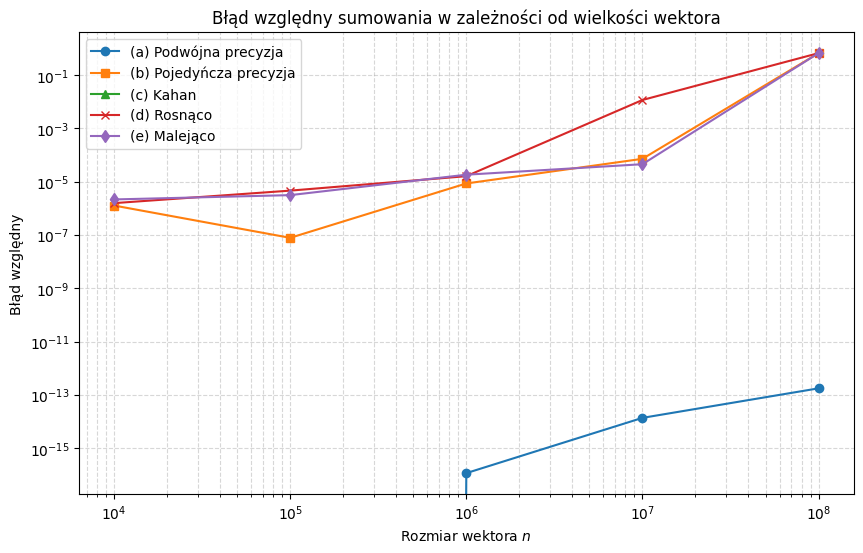

In [32]:
plt.figure(figsize=(10, 6))

plt.loglog(n_sizes, err_a, 'o-', label='(a) Podwójna precyzja')
plt.loglog(n_sizes, err_b, 's-', label='(b) Pojedyńcza precyzja')
plt.loglog(n_sizes, err_c, '^-', label='(c) Kahan')
plt.loglog(n_sizes, err_d, 'x-', label='(d) Rosnąco')
plt.loglog(n_sizes, err_e, 'd-', label='(e) Malejąco')

plt.xlabel('Rozmiar wektora $n$')
plt.ylabel('Błąd względny')
plt.title('Błąd względny sumowania w zależności od wielkości wektora')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

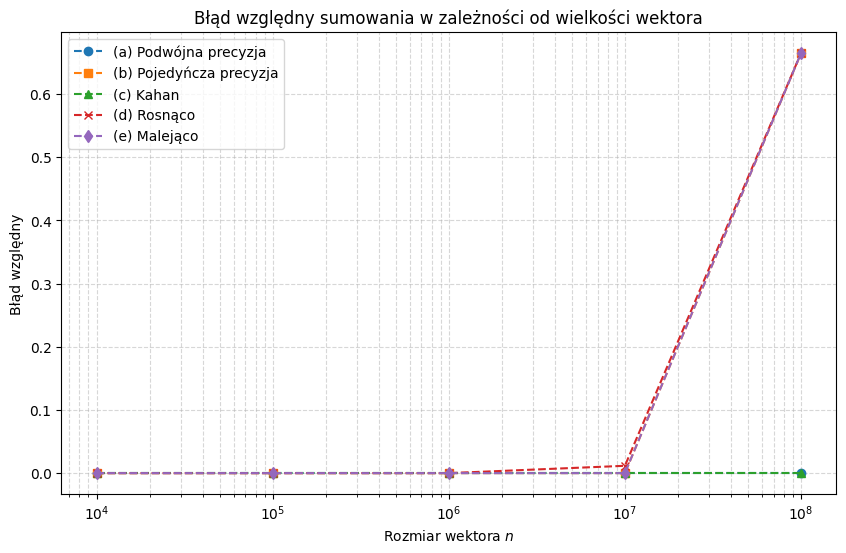

In [51]:
plt.figure(figsize=(10, 6))

plt.semilogx(n_sizes, err_a, 'o--', label='(a) Podwójna precyzja')
plt.semilogx(n_sizes, err_b, 's--', label='(b) Pojedyńcza precyzja')
plt.semilogx(n_sizes, err_c, '^--', label='(c) Kahan')
plt.semilogx(n_sizes, err_d, 'x--', label='(d) Rosnąco')
plt.semilogx(n_sizes, err_e, 'd--', label='(e) Malejąco')

plt.xlabel('Rozmiar wektora $n$')
plt.ylabel('Błąd względny')
plt.title('Błąd względny sumowania w zależności od wielkości wektora')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()